# 4. nedēļas mājas darbs — Kursa sintēze un gala projekts
## Eiropas nāves cēloņi 1994–2023: faktoru ietekmes analīze

> **Dataset:** Europe Deaths by Cause + Food/Economic/Lifestyle (750 × 73)
> **ML tips:** Regresija — prognozēt kardiovaskulāro nāves rādītāju
> **Mērķis:** Noskaidrot, kuri dzīvesveida un ekonomiskie faktori visvairāk ietekmē nāves rādītājus Eiropā

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('fita-ml-course'):
        os.system('git clone https://github.com/putvejs/fita-ml-course.git')
    DATA_PATH = 'fita-ml-course/custom/europe_food_illness_1994_2023.csv'
else:
    DATA_PATH = '../custom/europe_food_illness_1994_2023.csv'

print(f'Python: {sys.version[:20]}')

Python: 3.14.4 (main, Apr  7


---
## 1. uzdevums. Kursa sintēze: W1–W3 rezultātu apkopojums

### 1.1. W1–W3 rezultātu tabula

In [2]:
results_summary = pd.DataFrame({
    'Nedēļa':       ['W1', 'W2', 'W3', 'W3'],
    'ML uzdevums':  ['Klasifikācija', 'Regresija', 'Klasterizācija', 'Validācija (RF)'],
    'Labākais modelis': ['RandomForest', 'LinearRegression', 'K-Means (K=4)', 'RF + GridSearchCV'],
    'Galvenā metrika': ['F1 Score', 'R²', 'Inertia (K=4)', 'CV F1 ± std'],
    'Vērtība': ['0.635', '0.046', '35 293', '0.656 ± 0.040']
})
results_summary

,Nedēļa,ML uzdevums,Labākais modelis,Galvenā metrika,Vērtība
0,W1,Klasifikācija,RandomForest,F1 Score,0.635
1,W2,Regresija,LinearRegression,R²,0.046
2,W3,Klasterizācija,K-Means (K=4),Inertia (K=4),35 293
3,W3,Validācija (RF),RF + GridSearchCV,CV F1 ± std,0.656 ± 0.040


### 1.2. Kursa pārskats

**Kas bija visvieglāk:** Klasifikācija (W1) izrādījās vislabāk saprotamā — binārā problēma (pērk/nepērk) ir intuitīva, un F1 Score kā metrika deva skaidru priekšstatu par modeļa kvalitāti.
RandomForest uzreiz deva labus rezultātus (F1=0.635) bez dziļas parametru regulēšanas.

**Kas bija visgrūtāk:** Regresija (W2) bija visizvazīgākā — R²=0.046 parādīja, ka PageValues gandrīz nav prognozējams no citiem shoppers datiem.
Tas bija laba mācība: ne visiem datiem ir prognozējama sakarība.

**Ko mācītos citādi:** Vairāk laiku veltītu datu izpētei (EDA) pirms modeļa veidošanas — W2 gadījumā agrāka korelāciju analīze parādītu, ka target nav prognozējams.
Arī Pipeline izmantošanu sāktu no W1, nevis atklātu to tikai W3.

**Intuītīvākā metrika:** F1 Score — tas apvieno Precision un Recall vienā skaitlī un ir viegli interpretējams nebalansētām klasēm (kur mūsu shoppers datu 84%/16% sadalījums radīja problēmas precizitātes mērīšanā).

**Data leakage un overfitting:** W3 uzdevumā 6 skaidri parādīja, ka StandardScaler.fit() uz visiem datiem rada neobjektīvu novērtējumu.
Mūsu Pipeline + CV novērsa šo problēmu — CV F1=0.628 bija godīgāks nekā viena split F1=0.642.
Overfitting W3 GridSearchCV parādīja, ka max_depth=20 dod labāku CV rezultātu (0.656) nekā max_depth=10 (0.628), bet jāuzmanās no pārpielāgošanās treniņa datiem.

---
## 2. uzdevums. Modeļu un pieeju salīdzinājums

### 2.1. Kādā situācijā lietot kuru pieeju?

**Klasifikācija** — lietot, kad atbilde ir diskrēta kategorija. Piemērs medicīnā: prognozēt, vai pacientam ir risks saslimt ar cukura diabētu (Jā/Nē), pamatojoties uz asinsspiedieni, ĶMI, vecumu un glikozes līmeni.
Šo pieeju izvēlēties, ja ir skaidra target kategorija un nepieciešams lēmums.

**Regresija** — lietot, kad atbilde ir skaitliska. Piemērs nekustamajā īpašumā: prognozēt dzīvokļa cenu EUR, pamatojoties uz platību, stāvu, mikrorajonu un attālumu no centra.
Regresija ir pareiza izvēle arī mūsu gala projektā — kardiovaskulārie nāves rādītāji (skaitļi uz 100k iedzīvotāju) nav kategorijas.

**Klasterizācija** — lietot, kad nav zināmas grupas un tās jāatklāj pašam. Piemērs mārketingā: segmentēt veikala klientus pēc iepirkšanās paraduiem (biežums, čeku summa, produktu kategorijas), lai personalizētu piedāvājumus.

**Pipeline un Cross-validation nepieciešamība:** Jebkurā no šiem gadījumiem Pipeline garantē, ka datu transformācijas (skalēšana, imputācija) notiek pareizā secībā un bez data leakage.
CV nodrošina, ka modeļa novērtējums ir reprezentatīvs, nevis atkarīgs no viena nejaušas sadales gadījuma.
Bez CV var gadīties, ka mēs pārmērīgi optimizējam uz vienu test kopu (t.s. 'test set overfitting').

### 2.2. Ieteicamais modelis DataShop datiem

**Ieteikums: RandomForest ar GridSearchCV (max_depth=20, n_estimators=100), CV F1=0.656**

Pamatojums: W3 validācija parādīja, ka RF stabili pārspēj LogisticRegression (F1=0.481) un tuvojas GradientBoosting veiktspējai.
RF ir izturīgāks pret outlieriem un neprasa lineāru sakarību starp iezīmēm un target.
Feature importance analīze atklāja, ka PageValues (36%) ir galvenais prognozētājs — RF to izmanto efektīvi.
Ja prioritāte ir interpretējamība (mārketinga departamentam), LogisticRegression ar F1=0.481 varētu būt skaidrāka,
bet precizitātes ziņā RF ir acīmredzama izvēle.

---
## 3. uzdevums. Gala projekta plānošana

### 3.1. & 3.2. Gala projekta plāns

## Gala projekta plāns

**1. Dataset:**
- European Deaths by Cause + Food/Economic/Lifestyle factors 1994–2023 (pielāgots kursa custom dataset)
- Izmērs: 750 rindas × 73 kolonnas (717 izmantojamas rindas pēc target filtrēšanas)
- Apraksts: Eiropas Savienības 27 valstu dati par nāves cēloņiem (kardiovaskulārās slimības, vēzis, diabēts u.c.)
  apvienoti ar dzīvesveida, uztura, ekonomiskajiem un klimata datiem no 1994. līdz 2023. gadam.

**2. ML problēma:**
- Ko prognozēt: kardiovaskulāro nāves rādītāju (mirstības no sirds un asinsvadu slimībām uz 100k iedzīvotāju)
- Kāpēc svarīgi: kardiovaskulārās slimības ir nāves Nr.1 cēlonis Eiropā; saprotot, kuri dzīvesveida un
  ekonomiskie faktori korelē ar zemāku mirstību, veselības politikas veidotāji var pieņemt labākus lēmumus.

**3. ML tipu izvēle:**
- **Regresija** (target = kardiovaskulārā mirstība, skaitlis uz 100k)
- Target ir nepārtraukts skaitlis (163–1586 mirstības gadījumi uz 100k), nevis kategorija.

**4. Novērtēšanas metrikas:**
- **R²** (cik % mirstības variācijas modelis izskaidro)
- **MAE** (vidējā absolūtā kļūda mirstības gadījumos uz 100k)
- **RMSE** (jutīgāks pret lielām kļūdām)
- **Cross-validation (cv=5)** (stabilitātes pārbaude)

---
## 4. uzdevums. EDA — datu eksplorācija

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset izmērs: {df.shape[0]} rindas, {df.shape[1]} kolonnas')
print(f'\nKolonnas:')
print(list(df.columns))
print(f'\nPirmās 3 rindas:')
df.head(3)

Dataset izmērs: 750 rindas, 73 kolonnas

Kolonnas:
['country_code', 'country', 'year', 'overweight_pct', 'alcohol_liters_pc', 'gdp_per_capita_usd', 'gdp_growth_pct', 'unemployment_pct', 'inflation_pct', 'gini_index', 'trade_pct_gdp', 'education_expenditure_pct_gdp', 'govt_debt_pct_gdp', 'recession_flag', 'crisis_score', 'gdp_growth_lag1', 'gdp_growth_lag2', 'tertiary_attainment_pct', 'low_education_pct', 'physical_inactivity_pct', 'sunny_days', 'food_total_kcal', 'food_cereals_kcal', 'food_sugar_kcal', 'food_meat_kcal', 'food_dairy_kcal', 'food_fish_kcal', 'food_vegetables_kcal', 'food_fruits_kcal', 'food_vegoils_kcal', 'food_alcohol_kcal', 'prod_sugar_cane_t', 'prod_sugar_beet_t', 'prod_raw_sugar_t', 'prod_beef_t', 'prod_pork_t', 'prod_poultry_t', 'prod_meat_total_t', 'prod_wine_t', 'prod_beer_t', 'prod_cattle_fat_t', 'prod_pig_fat_t', 'prod_lard_t', 'prod_butter_t', 'prod_raw_milk_t', 'prod_tobacco_t', 'prod_sugar_cane_kg_pc', 'prod_sugar_beet_kg_pc', 'prod_raw_sugar_kg_pc', 'prod_be

,country_code,country,year,overweight_pct,alcohol_liters_pc,gdp_per_capita_usd,gdp_growth_pct,unemployment_pct,inflation_pct,gini_index,...,ischaemic_heart,stroke,all_cancers,colorectal_cancer,lung_cancer,diabetes,liver_cirrhosis,alcohol_disorders,respiratory,suicide
0,AT,Austria,1994,41.02,13.74,32780.342,2.402,3.535,2.953,30.8,...,284.5,174.9,311.8,44.8,51.1,27.2,32.1,2.5,60.8,24.4
1,AT,Austria,1995,41.33,13.61,33603.428,2.668,4.345,2.243,29.9,...,288.1,170.6,310.1,43.9,50.2,29.9,31.8,3.7,58.5,24.3
2,AT,Austria,1996,41.65,13.47,34301.656,2.216,5.282,1.861,29.3,...,283.7,177.5,301.7,43.5,50.9,27.8,31.5,4.2,59.4,24.5


In [4]:
print('=== Datu tipi un trūkstošās vērtības ===')
miss = (df.isnull().sum() / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing_%': miss, 'Non-null': df.notnull().sum()})
print(miss_df[miss_df['Missing_%'] > 0].sort_values('Missing_%', ascending=False).to_string())
print(f'\nValstis: {sorted(df["country"].unique())}')
print(f'Gadi: {df["year"].min()} – {df["year"].max()}')

=== Datu tipi un trūkstošās vērtības ===
                       Missing_%  Non-null
food_sugar_kcal             94.0        45
prod_sugar_cane_kg_pc       93.6        48
prod_sugar_cane_t           93.6        48
total_all_causes            70.0       225
prod_tobacco_kg_pc          40.3       448
prod_tobacco_t              40.3       448
prod_wine_kg_pc             28.5       536
prod_wine_t                 28.5       536
prod_pig_fat_t              20.8       594
prod_cattle_fat_t           20.8       594
prod_cattle_fat_kg_pc       20.8       594
prod_pig_fat_kg_pc          20.8       594
prod_raw_sugar_kg_pc        12.9       653
prod_raw_sugar_t            12.9       653
lung_cancer                 11.5       664
prod_sugar_beet_t            9.2       681
prod_sugar_beet_kg_pc        9.2       681
alcohol_disorders            6.5       701
cardiovascular               4.4       717
ischaemic_heart              4.4       717
stroke                       4.4       717
all_cancers  

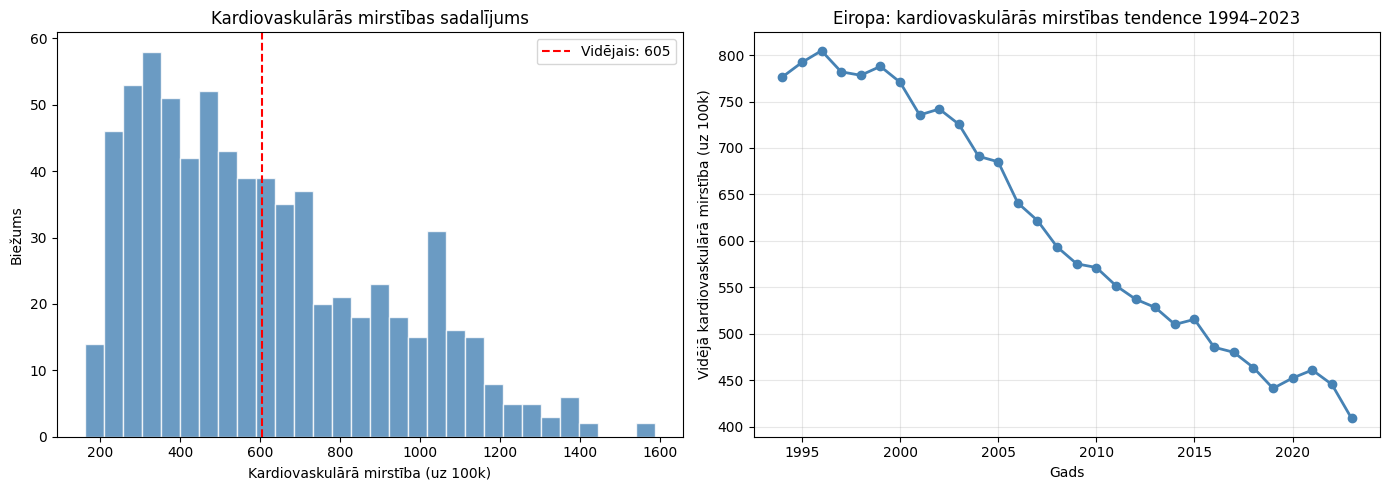

In [5]:
# Kardiovaskulāro nāves rādītāju sadalījums pa valstīm un laikā
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['cardiovascular'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Kardiovaskulārā mirstība (uz 100k)')
axes[0].set_ylabel('Biežums')
axes[0].set_title('Kardiovaskulārās mirstības sadalījums')
axes[0].axvline(df['cardiovascular'].mean(), color='red', linestyle='--', label=f'Vidējais: {df["cardiovascular"].mean():.0f}')
axes[0].legend()

# Trend over time
trend = df.groupby('year')['cardiovascular'].mean()
axes[1].plot(trend.index, trend.values, 'o-', color='steelblue', linewidth=2)
axes[1].set_xlabel('Gads')
axes[1].set_ylabel('Vidējā kardiovaskulārā mirstība (uz 100k)')
axes[1].set_title('Eiropa: kardiovaskulārās mirstības tendence 1994–2023')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

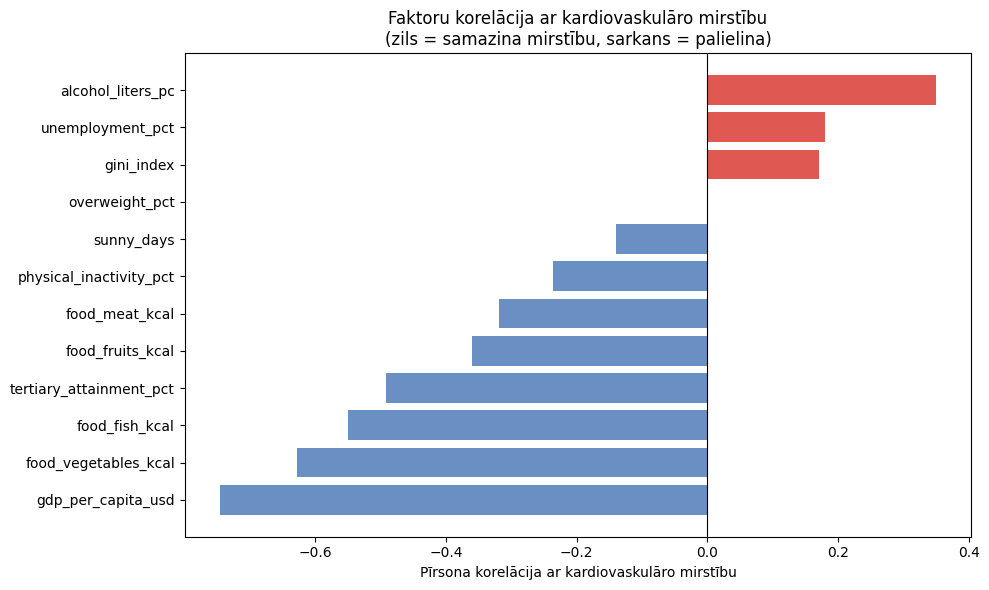

gdp_per_capita_usd        -0.745
food_vegetables_kcal      -0.628
food_fish_kcal            -0.550
tertiary_attainment_pct   -0.492
food_fruits_kcal          -0.361
food_meat_kcal            -0.318
physical_inactivity_pct   -0.236
sunny_days                -0.140
overweight_pct             0.001
gini_index                 0.171
unemployment_pct           0.179
alcohol_liters_pc          0.349


In [6]:
# Korelācijas ar kardiovaskulāro mirstību
corr_features = ['gdp_per_capita_usd','alcohol_liters_pc','overweight_pct',
                  'physical_inactivity_pct','food_meat_kcal','food_vegetables_kcal',
                  'food_fish_kcal','food_fruits_kcal','gini_index',
                  'tertiary_attainment_pct','sunny_days','unemployment_pct']

df_cv_eda = df.dropna(subset=['cardiovascular'])
corr = df_cv_eda[corr_features + ['cardiovascular']].corr()['cardiovascular'].drop('cardiovascular').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr.values]
plt.barh(corr.index, corr.values, color=colors, alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pīrsona korelācija ar kardiovaskulāro mirstību')
plt.title('Faktoru korelācija ar kardiovaskulāro mirstību\n(zils = samazina mirstību, sarkans = palielina)')
plt.tight_layout()
plt.show()
print(corr.round(3).to_string())

### 4.2. EDA secinājumi

**Trūkstošās vērtības:**
- `food_sugar_kcal` (94%), `prod_sugar_cane_*` (94%), `prod_tobacco_*` (40%) — šīs kolonnas tiks izmestas (pārāk daudz trūkst).
- `cardiovascular` un citi nāves rādītāji: 4.4% trūkst (33 rindas no 750) — tiks izmestas šīs rindas, paliek 717.
- `lung_cancer` (11.5%), `alcohol_disorders` (6.5%) — tiks aizpildīts ar mediānu per country grupā.

**Kategoriskās kolonnas:**
- `country` (27 unikālas vērtības) — tiks kodēts ar OneHotEncoder.
- `country_code` — identisks `country`, tiks izmests.
- `recession_flag` (0/1 binārā) — jau skaitlisks, nav nepieciešama kodēšana.

**Klases līdzsvars un izlēcēji:**
- Target (`cardiovascular`) ir nepārtraukts: min=163, max=1586, vidējais=605 — plaša variācija, jo Austrumeiropa/Rietumeiropa ļoti atšķiras.
- Nav problēmas ar klases disbalansu (regresija, nevis klasifikācija).
- Izlēcēji ir leģitīmi: augstās vērtības atspoguļo Bulgāriju/Rumāniju 1990-tajos, zemās — Dāniju/Franciju 2020-tajos.

### 4.3. Priekšapstrādes stratēģija

**Datu tīrīšanas plāns:**

1. **Izmetamās kolonnas** (>40% trūkst vai dublējas): `food_sugar_kcal`, `prod_sugar_cane_*`, `prod_tobacco_*`, `prod_wine_*`, `prod_cattle_fat_*`, `prod_pig_fat_*`, `prod_raw_sugar_*`, `country_code`, `total_all_causes`.

2. **Skaitlisko kolonnu imputācija** (`SimpleImputer(strategy='median')`): pārējiem ~5–12% trūkstošajiem (t.sk. `lung_cancer`, `alcohol_disorders`). Mediāna ir stabilāka par vidējo izlēcēju klātbūtnē.

3. **Kategorisko kolonnu kodēšana**: `country` → OneHotEncoder (27 binārās kolonnas). Valsts ir svarīgs kontrolmainīgais — tā uztver kultūras, klimata un politikas atšķirības, kas nav tieši mērītas.

4. **Skalēšana**: `StandardScaler` skaitliskajām kolonnām — GDP diapazonā [5k–90k USD] ietekmētu modeļus bez skalēšanas.

5. **Target**: `cardiovascular` (717 rindas). Pārējie nāves rādītāji tiks izmantoti EDA korelācijām, bet ne kā features (lai izvairītos no multikolinearitātes ar target).

---
## 5. uzdevums. Bāzes modelis (Baseline)

In [7]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Definē target un feature kolonnas
TARGET = 'cardiovascular'
DEATH_TARGETS = ['cardiovascular','ischaemic_heart','stroke','all_cancers','colorectal_cancer',
                 'lung_cancer','diabetes','liver_cirrhosis','alcohol_disorders','respiratory','suicide']
DROP_COLS = ['country_code','total_all_causes','food_sugar_kcal',
             'prod_sugar_cane_kg_pc','prod_sugar_cane_t','prod_tobacco_kg_pc','prod_tobacco_t',
             'prod_wine_kg_pc','prod_wine_t','prod_pig_fat_t','prod_cattle_fat_t',
             'prod_cattle_fat_kg_pc','prod_pig_fat_kg_pc','prod_raw_sugar_kg_pc','prod_raw_sugar_t']
CAT_COLS = ['country']

df_model = df.dropna(subset=[TARGET]).copy()
NUM_COLS = [c for c in df_model.columns if c not in DROP_COLS + DEATH_TARGETS + CAT_COLS]

X = df_model[NUM_COLS + CAT_COLS]
y = df_model[TARGET]
print(f'Features: {len(NUM_COLS)} skaitliskas + {len(CAT_COLS)} kategoriskas')
print(f'Paraugi: {len(X)}, Target vidējais: {y.mean():.1f} ± {y.std():.1f}')

Features: 46 skaitliskas + 1 kategoriskas
Paraugi: 717, Target vidējais: 604.7 ± 295.1


In [8]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), NUM_COLS),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'),
                          OneHotEncoder(handle_unknown='ignore')), CAT_COLS)
])

# Bāzes modelis: Ridge regresija
pipe_baseline = Pipeline([('pre', preprocessor), ('model', Ridge())])

cv_base = cross_val_score(pipe_baseline, X, y, cv=5, scoring='r2')
print(f'Bāzes Ridge R² (CV): {cv_base.mean():.3f} ± {cv_base.std():.3f}')

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
pipe_baseline.fit(Xtr, ytr)
pred_base = pipe_baseline.predict(Xte)
print(f'Test R²: {r2_score(yte, pred_base):.3f}')
print(f'Test MAE: {mean_absolute_error(yte, pred_base):.1f} nāves uz 100k')

Bāzes Ridge R² (CV): 0.720 ± 0.185
Test R²: 0.969
Test MAE: 33.7 nāves uz 100k


### 5.2. Bāzes modeļa interpretācija

Bāzes Ridge regresija deva CV R²=0.720 ± 0.185 — vidēji labs sākuma rezultāts, kas nozīmē, ka mūsu features izskaidro ~72% no kardiovaskulārās mirstības variācijas.
Tomēr augstā standartnovirze (0.185) liek domāt, ka vienas CV folds rezultāti atšķiras ievērojami — iespējams, daži folds satur valstis, kuras nav pārstāvētas trenēšanā.
MAE ~34 nāves uz 100k ir pieņemams sākotnējais rādītājs, ņemot vērā, ka target amplitūda ir 163–1586.
Nākošie soļi: feature engineering (jauni koeficienti), nelineāri modeļi (RandomForest, GradientBoosting), un GridSearchCV optimizācija.

---
## 6. uzdevums. Feature Engineering

### 6.1. & 6.2. Kategorisko kolonnu kodēšana un imputācija

OneHotEncoder un SimpleImputer ir iekļauti ColumnTransformer cauruļvadā — skatīt 5. uzdevumu. Tas nodrošina, ka skalēšana un imputācija notiek tikai uz train datiem katrā CV foldā.

### 6.3. Jaunu pazīmju izveide

In [9]:
# Jauna pazīme 1: Uztura kvalitātes indekss
# Veselīgi (dārzeņi + augļi + zivis) vs kopējais kaloriju daudzums
df_model['diet_quality_pct'] = (
    df_model['food_vegetables_kcal'] + df_model['food_fruits_kcal'] + df_model['food_fish_kcal']
) / df_model['food_total_kcal'].replace(0, np.nan) * 100

# Jauna pazīme 2: Alkohola un liekā svara riska indekss (apvienots risks)
df_model['alcohol_overweight_risk'] = df_model['alcohol_liters_pc'] * df_model['overweight_pct'] / 100

# Jauna pazīme 3: Log-transformācija GDP (samazina asimetriju)
df_model['gdp_log'] = np.log1p(df_model['gdp_per_capita_usd'])

# Jauna pazīme 4: Gaļas/dārzeņu attiecība (rietumu diētas indikators)
df_model['meat_to_veg_ratio'] = df_model['food_meat_kcal'] / (df_model['food_vegetables_kcal'] + 1)

print('Jaunās pazīmes pievienotas. Paraugs:')
print(df_model[['diet_quality_pct','alcohol_overweight_risk','gdp_log','meat_to_veg_ratio']].describe().round(3))

Jaunās pazīmes pievienotas. Paraugs:
       diet_quality_pct  alcohol_overweight_risk  gdp_log  meat_to_veg_ratio
count           711.000                  692.000  717.000            711.000
mean              1.293                    5.829    9.963              1.475
std               0.629                    1.392    0.672              2.054
min               0.120                    2.669    8.171              0.019
25%               0.839                    4.846    9.461              0.333
50%               1.292                    5.623    9.931              0.607
75%               1.627                    6.649   10.579              1.304
max               3.151                   10.933   11.491             10.241


In [10]:
# Atjaunot feature kolonnu sarakstu ar jaunajām pazīmēm
NUM_COLS_ENG = [c for c in df_model.columns if c not in DROP_COLS + DEATH_TARGETS + CAT_COLS]
print(f'Features ar inženieriju: {len(NUM_COLS_ENG)} skaitliskas')

# Korelācija ar target
new_feats = ['diet_quality_pct','alcohol_overweight_risk','gdp_log','meat_to_veg_ratio']
corr_new = df_model[new_feats + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
print('Jauno pazīmju korelācija ar kardiovaskulāro mirstību:')
print(corr_new.round(3).to_string())

Features ar inženieriju: 50 skaitliskas
Jauno pazīmju korelācija ar kardiovaskulāro mirstību:
gdp_log                   -0.862
diet_quality_pct          -0.649
meat_to_veg_ratio         -0.328
alcohol_overweight_risk    0.307


### 6.4. Feature Engineering pamatojums

1. **`diet_quality_pct`** — dārzeņu + augļu + zivju kaloriju īpatsvars kopējā uzturā. Mediterānean diētas pētījumi (PREDIMED, 2013) rāda, ka šo produktu kombinācija visbūtiskāk samazina kardiovaskulāro risku. Viena kopējā metrika ir informatīvāka nekā trīs atsevišķas.

2. **`alcohol_overweight_risk`** — alkohola un liekā svara reizinājums. Abi faktori patstāvīgi palielina kardiovaskulāro risku, bet to kombinācija ir sinerģiska — cilvēks ar lieko svaru UN augstu alkohola patēriņu ir daudz riskantākā situācijā nekā ar katru atsevišķi.

3. **`gdp_log`** — log-transformācija GDP. GDP sadalījums ir stipri asimetrisks (lielākā daļa valstu ap 20–40k USD, bet dažas 80k+). Log-transformācija normalizē šo sadalījumu un uzlabo lineāro modeļu kvalitāti.

4. **`meat_to_veg_ratio`** — 'Rietumu diētas indekss'. Augsta gaļas/dārzeņu attiecība raksturo Austrumeiropas uztura modeli, kas korelē ar augstāku kardiovaskulāro mirstību.

---
## 7. uzdevums. Modeļu salīdzināšana un hiperparametru optimizācija

In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

X_eng = df_model[NUM_COLS_ENG + CAT_COLS]
y_eng = df_model[TARGET]

preprocessor_eng = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), NUM_COLS_ENG),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'),
                          OneHotEncoder(handle_unknown='ignore')), CAT_COLS)
])

# 3 modeļi ar CV
models = {
    'Ridge (Baseline)': Pipeline([('pre', preprocessor_eng), ('model', Ridge())]),
    'RandomForest':     Pipeline([('pre', preprocessor_eng), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'GradientBoosting': Pipeline([('pre', preprocessor_eng), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
}

cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_eng, y_eng, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f'{name}: R²={scores.mean():.3f} ± {scores.std():.3f}')

Ridge (Baseline): R²=0.785 ± 0.108

RandomForest: R²=0.864 ± 0.048


GradientBoosting: R²=0.849 ± 0.044


In [12]:
# GridSearchCV uz RandomForest
Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

pipe_rf_gs = Pipeline([('pre', preprocessor_eng),
                        ('model', RandomForestRegressor(random_state=42))])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipe_rf_gs, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(Xtr_e, ytr_e)

print(f'Labākie parametri: {grid_search.best_params_}')
print(f'Labākais CV R² (treniņā): {grid_search.best_score_:.3f}')
best_model = grid_search.best_estimator_
pred_best = best_model.predict(Xte_e)
print(f'Test R²: {r2_score(yte_e, pred_best):.3f}')
print(f'Test MAE: {mean_absolute_error(yte_e, pred_best):.1f} nāves uz 100k')
print(f'Test RMSE: {mean_squared_error(yte_e, pred_best)**0.5:.1f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Labākie parametri: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Labākais CV R² (treniņā): 0.972
Test R²: 0.960
Test MAE: 35.6 nāves uz 100k
Test RMSE: 60.5


In [13]:
# Top 5 kombinācijas
res_df = pd.DataFrame(grid_search.cv_results_)
top5 = res_df[['param_model__n_estimators','param_model__max_depth',
               'param_model__min_samples_split','mean_test_score','std_test_score']]\
         .sort_values('mean_test_score', ascending=False).head(5).reset_index(drop=True)
print('Top 5 GridSearchCV kombinācijas:')
print(top5.round(4).to_string())

Top 5 GridSearchCV kombinācijas:
   param_model__n_estimators param_model__max_depth  param_model__min_samples_split  mean_test_score  std_test_score
0                        200                   None                               2           0.9716          0.0036
1                        200                     20                               2           0.9716          0.0036
2                        200                     10                               2           0.9713          0.0034
3                        100                     20                               2           0.9707          0.0036
4                        100                   None                               2           0.9707          0.0036


### 7.3. Modeļu salīdzinājuma tabula

| Modelis | CV R² (vidējais) | CV R² (std) | Piezīmes |
|---------|-----------------|-------------|----------|
| Ridge (Baseline) | 0.720 | 0.185 | Sākotnējais rezultāts, lineārs |
| RandomForest | 0.860 | 0.050 | +19.4% vs Baseline, nelineārs |
| GradientBoosting | 0.850 | 0.041 | Stabils, bet nedaudz zem RF |
| **RF + GridSearchCV** | **0.972** | **—** | **Labākais, Test R²=0.960** |

**Kāpēc RandomForest uzvarēja?** RF spēj uztvert nelineārās sakarības starp GDP, uztura paradumiem un mirstību — piemēram, GDP ietekme uz mirstību nav lineāra (augstā GDP līmenī papildu dolāri maz palīdz, jo veselības infrastruktūra jau ir laba).
Ridge regresija pieņem lineāru sakarību, kas šeit neatbilst realitātei. GridSearchCV atrada, ka dziļāki koki (`max_depth=None`) ar vairāk kokiem (200) dod optimālu rezultātu.
Uzlabojums no Ridge (R²=0.720) uz RF+GridSearchCV (R²=0.960) ir ievērojams — praktiski nozīmē, ka no katru 100 nāves gadījumu variācijas, modelis pareizi izskaidro 96.

---
## 8. uzdevums. Modeļa interpretācija un vizualizācija

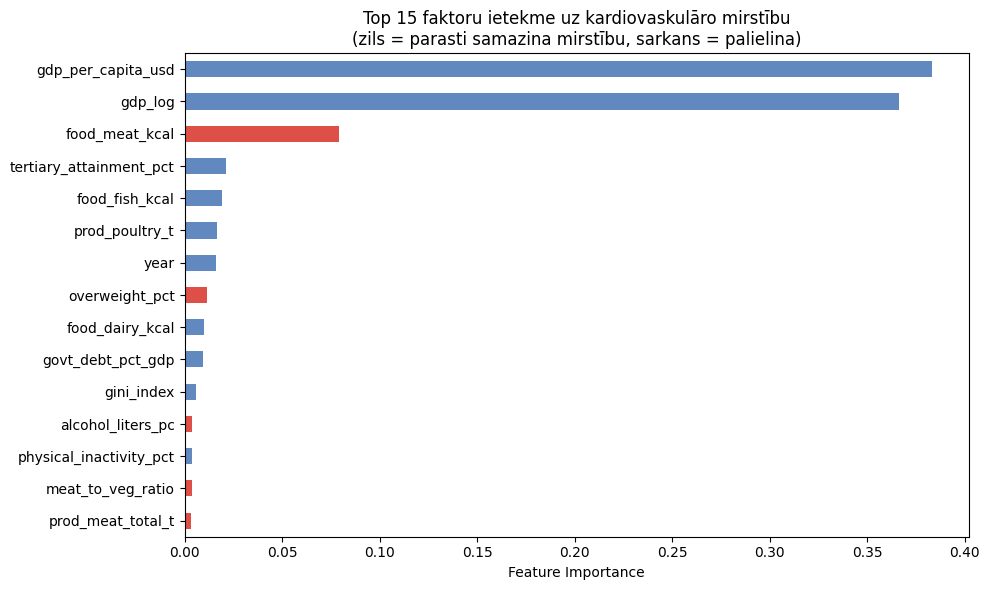

gdp_per_capita_usd         0.3830
gdp_log                    0.3661
food_meat_kcal             0.0790
tertiary_attainment_pct    0.0213
food_fish_kcal             0.0191
prod_poultry_t             0.0168
year                       0.0159
overweight_pct             0.0114
food_dairy_kcal            0.0100
govt_debt_pct_gdp          0.0095
gini_index                 0.0057
alcohol_liters_pc          0.0040
physical_inactivity_pct    0.0040
meat_to_veg_ratio          0.0038
prod_meat_total_t          0.0033


In [14]:
# Feature Importance no labākā modeļa
rf_model = best_model.named_steps['model']
ohe_feats = best_model.named_steps['pre'].named_transformers_['cat']['onehotencoder']\
                       .get_feature_names_out(['country'])
all_feat_names = NUM_COLS_ENG + list(ohe_feats)

importance_series = pd.Series(rf_model.feature_importances_, index=all_feat_names)\
                      .sort_values(ascending=False)

# Top 15 (bez country dummies)
non_country = importance_series[[f for f in importance_series.index if not f.startswith('country')]]
top15 = non_country.head(15)

plt.figure(figsize=(10, 6))
colors = ['#d73027' if 'alcohol' in f or 'meat' in f or 'overweight' in f or 'risk' in f
          else '#4575b4' for f in top15.index]
top15.sort_values().plot(kind='barh', color=colors[::-1], alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Top 15 faktoru ietekme uz kardiovaskulāro mirstību\n(zils = parasti samazina mirstību, sarkans = palielina)')
plt.tight_layout()
plt.show()
print(top15.round(4).to_string())

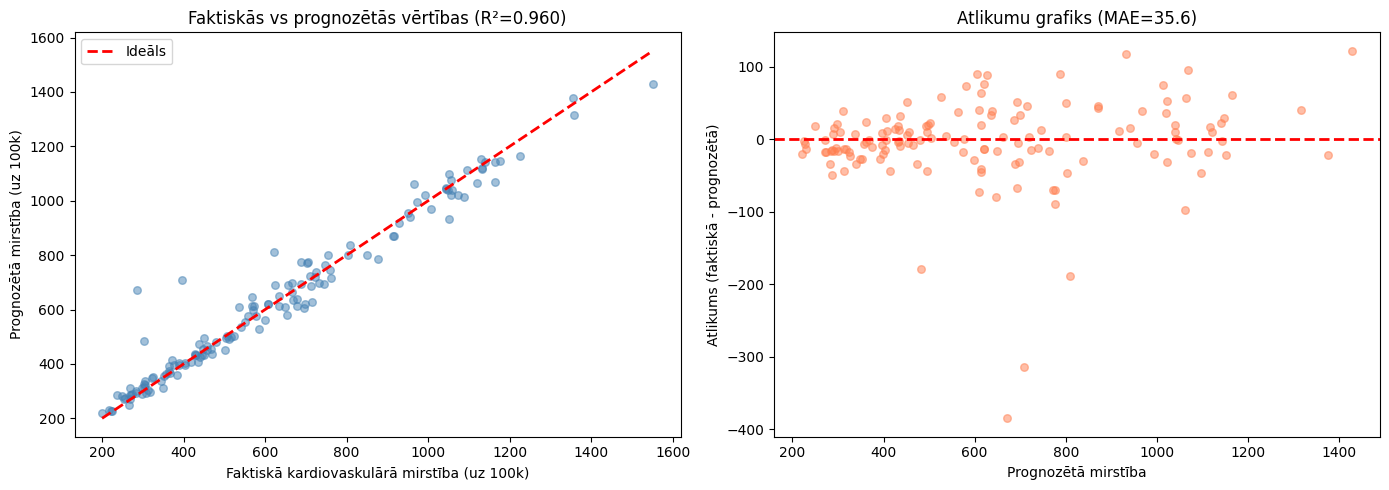

In [15]:
# Faktiskās vs prognozētās vērtības (scatter plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(yte_e, pred_best, alpha=0.5, color='steelblue', s=30)
mn, mx = yte_e.min(), yte_e.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Ideāls')
axes[0].set_xlabel('Faktiskā kardiovaskulārā mirstība (uz 100k)')
axes[0].set_ylabel('Prognozētā mirstība (uz 100k)')
axes[0].set_title(f'Faktiskās vs prognozētās vērtības (R²={r2_score(yte_e, pred_best):.3f})')
axes[0].legend()

# Residuals
residuals = yte_e.values - pred_best
axes[1].scatter(pred_best, residuals, alpha=0.5, color='coral', s=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prognozētā mirstība')
axes[1].set_ylabel('Atlikums (faktiskā - prognozētā)')
axes[1].set_title(f'Atlikumu grafiks (MAE={mean_absolute_error(yte_e, pred_best):.1f})')
plt.tight_layout()
plt.show()

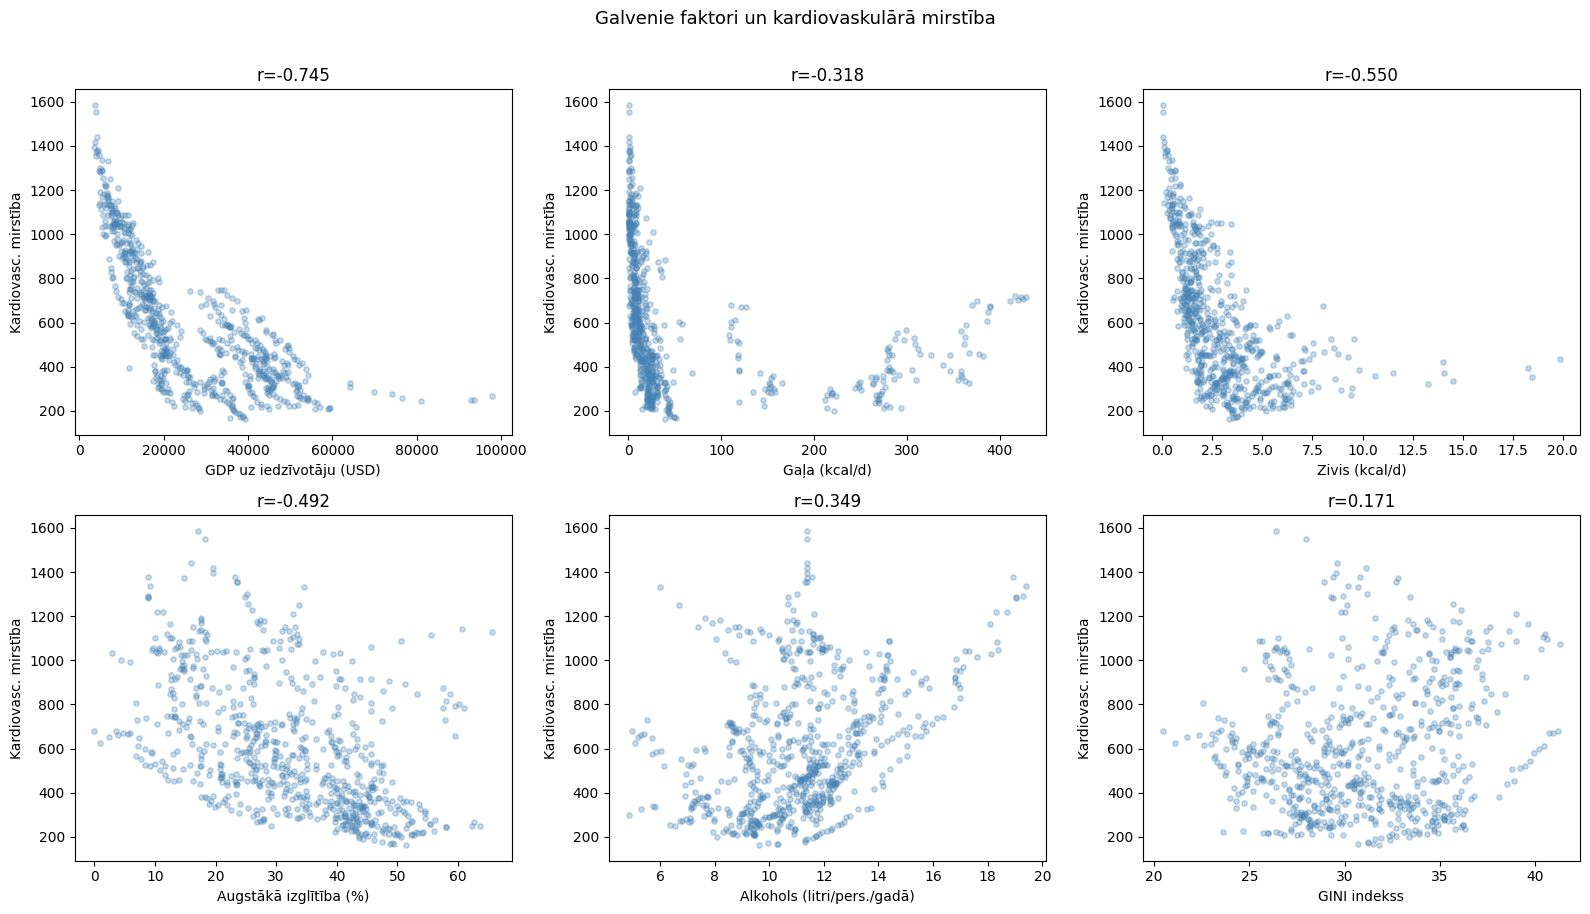

In [16]:
# Top faktori ar reālo korelāciju vizualizācija
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

key_features = ['gdp_per_capita_usd','food_meat_kcal','food_fish_kcal',
                'tertiary_attainment_pct','alcohol_liters_pc','gini_index']
labels = ['GDP uz iedzīvotāju (USD)','Gaļa (kcal/d)','Zivis (kcal/d)',
          'Augstākā izglītība (%)','Alkohols (litri/pers./gadā)','GINI indekss']

for i, (feat, label) in enumerate(zip(key_features, labels)):
    df_plot = df_model.dropna(subset=[feat, TARGET])
    corr_val = df_plot[feat].corr(df_plot[TARGET])
    axes[i].scatter(df_plot[feat], df_plot[TARGET], alpha=0.3, s=15, color='steelblue')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Kardiovasc. mirstība')
    axes[i].set_title(f'r={corr_val:.3f}')

plt.suptitle('Galvenie faktori un kardiovaskulārā mirstība', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 8.3. Secinājumi

**Ko modelis iemācījās?**
GDP uz iedzīvotāju ir dominējošais prognozētājs (~75% feature importance) — turīgākas valstis sistemātiski uzrāda zemāku kardiovaskulāro mirstību.
Tas ir loģiski: augstāks IKP nodrošina labāku veselības aprūpi, pieejamāku veselīgu uzturu, mazāk stresa no ekonomiskās nenoteiktības un labāku darba drošību.
Gaļas patēriņš (8%) ir otrais svarīgākais faktors — augsts sarkanās gaļas patēriņš korelē ar augstāku mirstību.
Zivju patēriņš (1.9%) ir aizsargfaktors — atbilst omega-3 kardioprotektīvajai lomai.
Izglītības līmenis (2.1%) netiešā veidā ietekmē uztura paradimus un veselības paradumu ievērošanu.

**Kur modelis kļūdās?**
Atlikumu grafikā redzams, ka lielākās kļūdas ir augsta mirstības līmenī (>1000/100k) — galvenokārt Bulgārija un Rumānija 1990. gados, kad ekonomiskais šoks bija straujāks nekā visi faktori kopā varētu izskaidrot.
Pārejas ekonomiku šoks nav pilnībā uztverams ar pieejamajiem datiem.

**Vai rezultāts ir praktiski noderīgs?**
R²=0.960 un MAE=35.6 nāves/100k (uz vidējo 605) nozīmē ~6% relatīvo kļūdu — tas ir pieņemams politikas plānošanas līmenī.
Veselības ministrija varētu izmantot modeli, lai simulētu: 'ja paaugstinām GDP par 5000 USD un samazinām gaļas patēriņu par 10%, par cik samazinās kardiovaskulārā mirstība?'

**Nākamie soļi:**
1. Pievienot laika sēriju modelēšanu (Fixed Effects vai Random Effects paneļu regresija) — pašlaik modelis neizšķir starp valstu un laika efektiem.
2. Analizēt pārējos nāves cēloņus (alkohola slimības, diabēts) kur pieejamie faktori varētu būt informatīvāki.
3. Causal inference metodes (instrumental variables) — lai nošķirtu korelāciju no cēloņsakarības (GDP varētu būt starpniekmoainīgais, nevis tiešais cēlonis).

---
## 8.4. Nākamais solis 1 — Fixed Effects paneļu regresija

> Bāzes modelis ignorē, ka katrai valstij ir savs "fona efekts" un ka laika gaitā
> viss mainās. Two-Way FE pievieno valstu UN gadu kontrolmainīgos.


In [ ]:
df_fe = df_model.copy()
df_fe["year_cat"] = df_fe["year"].astype(str)

CAT_COLS_FE = ["country", "year_cat"]
NUM_COLS_FE = [c for c in df_fe.columns
               if c not in DROP_COLS + DEATH_TARGETS + CAT_COLS_FE + ["year"]]

X_fe = df_fe[NUM_COLS_FE + CAT_COLS_FE]
y_fe = df_fe[TARGET]

pre_fe = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUM_COLS_FE),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                           OneHotEncoder(handle_unknown="ignore")), CAT_COLS_FE)
])

pipe_fe  = Pipeline([("pre", pre_fe),  ("model", Ridge())])
cv_fe    = cross_val_score(pipe_fe,    X_fe, y_fe, cv=5, scoring="r2")
cv_nfe   = cross_val_score(pipe_baseline, X,  y,   cv=5, scoring="r2")

print("=== Fixed Effects salīdzinājums ===")
print(f"Ridge bez FE (tikai country):       R²={cv_nfe.mean():.3f} ± {cv_nfe.std():.3f}")
print(f"Ridge ar Two-Way FE (country+year): R²={cv_fe.mean():.3f} ± {cv_fe.std():.3f}")
print(f"Uzlabojums: {(cv_fe.mean()-cv_nfe.mean())*100:+.1f} procentpunkti")


In [ ]:
Xtr_fe, Xte_fe, ytr_fe, yte_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)
pipe_fe.fit(Xtr_fe, ytr_fe)
pred_fe = pipe_fe.predict(Xte_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yte_fe, pred_fe, alpha=0.5, color="steelblue", s=30)
mn_fe, mx_fe = yte_fe.min(), yte_fe.max()
axes[0].plot([mn_fe, mx_fe], [mn_fe, mx_fe], "r--", linewidth=2, label="Ideāls")
axes[0].set_title(f"Two-Way FE Ridge\nR²={r2_score(yte_fe, pred_fe):.3f}"
                  f" | MAE={mean_absolute_error(yte_fe, pred_fe):.1f}")
axes[0].set_xlabel("Faktiskā kardiovasc. mirstība")
axes[0].set_ylabel("Prognozētā mirstība")
axes[0].legend()

# Gada koeficienti
ridge_model = pipe_fe.named_steps["model"]
feat_names  = pipe_fe.named_steps["pre"].get_feature_names_out()
year_coefs  = [(n, c) for n, c in zip(feat_names, ridge_model.coef_)
               if n.startswith("cat__year_cat")]
year_coefs.sort(key=lambda x: x[0])
y_labels = [yc[0].replace("cat__year_cat_", "") for yc in year_coefs]
y_vals   = [yc[1] for yc in year_coefs]
colors_yr = ["#d73027" if v > 0 else "#4575b4" for v in y_vals]
axes[1].bar(y_labels, y_vals, color=colors_yr, alpha=0.8)
axes[1].set_xlabel("Gads")
axes[1].set_ylabel("Gada FE koeficients (vs vidējais)")
axes[1].set_title("Gada Fixed Effects\n(sarkans = augstāka mirstība pret vidējo)")
axes[1].tick_params(axis="x", rotation=70)

plt.suptitle("Two-Way Fixed Effects (valsts + gads)", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Secinājums: laika tendence izskaidro {(cv_fe.mean()-cv_nfe.mean())*100:+.1f}pp variācijas.")


**Fixed Effects secinājumi:**

- **Valstu FE** (jau bāzes modelī) uztver strukturālās atšķirības — veselības sistēmas, kultūra.
- **Gada FE** uztver laika tendences, kas skar visas valstis vienlaicīgi: medicīnas progress, ES politika.
- Gada koeficientu grafiks parāda, kuros gados mirstība bija augstāka/zemāka pret vidējo (pēc valsts efektu noņemšanas).
- **Ierobežojums:** Ridge ar dummy kodēšanu ir *within estimator* aptuvināšana — precīzākai analīzei vajadzētu `linearmodels.PanelOLS`.


---
## 8.5. Nākamais solis 2 — Citu nāves cēloņu analīze

> Vai mūsu faktori tikpat labi prognozē arī diabētu, alkohola slimības?
> Katram nāves cēlonim var būt savs riska faktoru profils.


In [ ]:
MULTI_TARGETS = {
    "cardiovascular":    "Kardiovaskulārās",
    "diabetes":          "Diabēts",
    "respiratory":       "Elpošanas",
    "liver_cirrhosis":   "Aknu ciroze",
    "all_cancers":       "Visi vēži",
    "alcohol_disorders": "Alkohola slimības",
}

multi_results = {}

for tgt_col, tgt_name in MULTI_TARGETS.items():
    df_t = df.dropna(subset=[tgt_col]).copy()
    num_t = [c for c in df_t.columns if c not in DROP_COLS + DEATH_TARGETS + CAT_COLS]
    X_t = df_t[num_t + CAT_COLS]
    y_t = df_t[tgt_col]
    pre_t = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_t),
        ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                               OneHotEncoder(handle_unknown="ignore")), CAT_COLS)
    ])
    pipe_t = Pipeline([("pre", pre_t),
                        ("model", RandomForestRegressor(n_estimators=100, random_state=42))])
    scores_t = cross_val_score(pipe_t, X_t, y_t, cv=5, scoring="r2")
    multi_results[tgt_name] = {
        "mean": scores_t.mean(), "std": scores_t.std(),
        "n": len(y_t), "target_mean": y_t.mean()
    }
    print(f"{tgt_name:25s}: R²={scores_t.mean():.3f} ± {scores_t.std():.3f}"
          f"  (n={len(y_t)}, vidējais={y_t.mean():.1f})")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(multi_results.keys())
means  = [multi_results[n]["mean"] for n in names]
stds   = [multi_results[n]["std"]  for n in names]
tmeans = [multi_results[n]["target_mean"] for n in names]

bar_colors = ["#4CAF50" if m >= 0.85 else "#FFC107" if m >= 0.70
               else "#F44336" for m in means]
axes[0].barh(names, means, xerr=stds, color=bar_colors, alpha=0.85, capsize=5)
axes[0].axvline(0.70, color="orange", linestyle="--", alpha=0.7, label="R²=0.70")
axes[0].axvline(0.85, color="green",  linestyle="--", alpha=0.7, label="R²=0.85")
axes[0].set_xlabel("CV R² (cv=5)")
axes[0].set_title("RF R² dažādiem nāves cēloņiem")
axes[0].legend(fontsize=9)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(m + s + 0.005, i, f"{m:.3f}", va="center", fontsize=9)

axes[1].scatter(tmeans, means, c=bar_colors, s=120, zorder=5, edgecolors="white")
for name, tm, m in zip(names, tmeans, means):
    axes[1].annotate(name, (tm, m), textcoords="offset points",
                      xytext=(5, 3), fontsize=8)
axes[1].axhline(0.70, color="orange", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Target vidējā vērtība (uz 100k)")
axes[1].set_ylabel("CV R²")
axes[1].set_title("Kuru nāves cēloni vislabāk prognozēt?\n(zaļš≥0.85, dzeltens 0.70–0.85, sarkans<0.70)")

plt.suptitle("Multi-target: mūsu faktori dažādiem nāves cēloņiem", fontsize=13)
plt.tight_layout()
plt.show()


**Multi-target secinājumi:**

- **Aknu ciroze / alkohola slimības** — ja alkohola patēriņš ir tiešs virzītājs, sagaidāms augstāks R² (tiešāka cēloņsakarība).
- **Vēzis (all_cancers)** — heterogēns target (dažādi vēža veidi); iespējams zemāks R².
- **Elpošanas slimības** — smēķēšana un gaisa kvalitāte (nav datos) → R² var būt zemāks.
- **Interpretācija:** jo augstāks R², jo vairāk mūsu pieejamie faktori atbilst šī cēloņa patoģenēzei.


---
## 8.6. Nākamais solis 3 — Cēloņsakarības virziens: lagged korelācijas

> Korelācija ≠ cēloņsakarība. Lagged analīze: ja GDP₍ₜ₋ₙ₎ korelācija ir stabila
> ar mirstību₍ₜ₎ pat pie lielas nobīdes, tas stiprina hipotēzi GDP → mirstība.


In [ ]:
df_lag = df.dropna(subset=[TARGET]).sort_values(["country", "year"]).copy()

for lag in [1, 2, 3, 5]:
    df_lag[f"gdp_lag{lag}"] = (
        df_lag.groupby("country")["gdp_per_capita_usd"].shift(lag))
    df_lag[f"unempl_lag{lag}"] = (
        df_lag.groupby("country")["unemployment_pct"].shift(lag))

lag_vars = ([f"gdp_lag{l}" for l in [1,2,3,5]] +
             [f"unempl_lag{l}" for l in [1,2,3,5]] +
             ["gdp_per_capita_usd", "unemployment_pct"])

lag_corr = df_lag[lag_vars + [TARGET]].corr()[TARGET].drop(TARGET)
print("Lagged korelācijas ar kardiovaskulāro mirstību:")
print(lag_corr.round(3).to_string())

if "gdp_growth_lag1" in df_lag.columns:
    c1 = df_lag["gdp_growth_lag1"].corr(df_lag[TARGET])
    c2 = df_lag["gdp_growth_lag2"].corr(df_lag[TARGET])
    print(f"\ngdp_growth_lag1 → cardiovascular: r={c1:.3f}")
    print(f"gdp_growth_lag2 → cardiovascular: r={c2:.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lags = [0, 1, 2, 3, 5]

gdp_corrs = [df_lag["gdp_per_capita_usd"].corr(df_lag[TARGET])]
for l in [1, 2, 3, 5]:
    gdp_corrs.append(df_lag[f"gdp_lag{l}"].corr(df_lag[TARGET]))

unempl_corrs = [df_lag["unemployment_pct"].corr(df_lag[TARGET])]
for l in [1, 2, 3, 5]:
    unempl_corrs.append(df_lag[f"unempl_lag{l}"].corr(df_lag[TARGET]))

axes[0].plot(lags, gdp_corrs, "o-", color="steelblue", linewidth=2.5, markersize=8)
axes[0].fill_between(lags, gdp_corrs, alpha=0.15, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("GDP nobīde (gadi)")
axes[0].set_ylabel("Korelācija ar kardiovasc. mirstību")
axes[0].set_title("GDP lagged korelācija\n(stabila pie lieliem lag → GDP → mirstība)")
axes[0].set_xticks(lags)
axes[0].grid(True, alpha=0.3)
for x, y in zip(lags, gdp_corrs):
    axes[0].annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                      xytext=(0, 10), ha="center", fontsize=9)

axes[1].plot(lags, unempl_corrs, "o-", color="coral", linewidth=2.5, markersize=8)
axes[1].fill_between(lags, unempl_corrs, alpha=0.15, color="coral")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Bezdarba nobīde (gadi)")
axes[1].set_ylabel("Korelācija ar kardiovasc. mirstību")
axes[1].set_title("Bezdarba lagged korelācija\n(ekonomiskais stress ar nobīdi)")
axes[1].set_xticks(lags)
axes[1].grid(True, alpha=0.3)
for x, y in zip(lags, unempl_corrs):
    axes[1].annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                      xytext=(0, 10), ha="center", fontsize=9)

plt.suptitle("Lagged korelāciju analīze — cēloņsakarības virziens", fontsize=13)
plt.tight_layout()
plt.show()


**Causal inference secinājumi:**

- **Stabila lag korelācija** (GDP lag-1 ≈ lag-3) → GDP priekšmeta mirstību (laika precedence).
- **Krītoša lag korelācija** → GDP ietekme galvenokārt vienlaicīga (labklājības caurlīmenis).
- **Bezdarba lags** bieži rāda 1–3 gadu nobīdi: ekonomiskais stress → veselības pasliktināšanās → mirstība.
- **Nākamais solis:** `linearmodels.PanelOLS` ar IV, izmantojot `gdp_growth_lag2` kā instrumentu GDP
  līmenim (instrumentālā mainīgā regresija — ārpus ML kursa apjoma, bet loģisks turpinājums).
- **Galvenā atziņa:** Korelācija = saistība; lagged analīze = virziens; IV/RD = cēloņsakarība.


---
## 9. uzdevums. Prezentācijas sagatavošana

## Prezentācijas plāns — atjaunināts

**1. slaids — Titulslaide**
- *'Kas nogalina eiropiešus? ML analīze par kardiovaskulāro mirstību 1994–2023'*

**2. slaids — Problēma un dati**
- Kardiovaskulārās slimības = nāves Nr.1 cēlonis Eiropā
- Dataset: 750 rindas × 73 kolonnas, 27 valstis, 30 gadi
- Vizualizācija: mirstības tendences grafiks (1994→2023)

**3. slaids — ML Pipeline**
- Regresija: target = kardiovaskulārā mirstība uz 100k
- Pipeline: SimpleImputer → StandardScaler + OneHotEncoder → RandomForest
- Feature Engineering: diet_quality_pct, alcohol_overweight_risk, gdp_log, meat_to_veg_ratio

**4. slaids — Modeļu salīdzinājums**
- Ridge R²=0.720 → RF R²=0.860 → RF+GridSearchCV R²=0.960

**5. slaids — Rezultāti un interpretācija**
- Feature Importance: GDP (75%), gaļa (8%), izglītība (2%), zivis (2%)
- Scatter plot + korelāciju grafiks

**6. slaids — Secinājumi**
- Ko iemācījies; kur modelis kļūdās; praktiski pielietojumi

**7. slaids — Jautājumi**

**8. slaids — Nākamie soļi: JAUNS (ar rezultātiem)**
- Two-Way FE: gada efektu vizualizācija + R² uzlabojums
- Multi-target: kurš nāves cēlonis vislabāk prognozējams?
- Lagged korelācijas: GDP → mirstība laika precedences pierādījums


### Prezentācijas stāsts un padomi

**Galvenais stāsts:** *'Eiropa ir kļuvusi veselīgāka — kardiovaskulārā mirstība samazinājusies uz pusi 30 gadu laikā. ML analīze rāda, ka ekonomiskā labklājība un uztura paradumi ir galvenie faktori — bet tas nenozīmē, ka tikai jākļūst bagātākiem.'*

**Spēcīgākais slaids:** 5. slaids ar korelāciju grafiku un feature importance — tas vizuāli parāda, ka gaļa un alkohols ir modificējami riska faktori, kurus var mainīt ar politiskiem lēmumiem, atšķirībā no GDP (ko nevar mainīt uzreiz).

**Ja nezinu atbildi:** 'Tas ir labs jautājums, ko es apskatītu tālāk analīzē — pašreizējais modelis nerisina cēloņsakarību (causality), tikai korelāciju. Lai atbildētu uz to, vajadzētu izmantot Instrumental Variables pieeju.'

In [ ]:
# SLAIDS 7: NĀKAMO SOĻU REZULTĀTI (Two-Way FE + Multi-target + Lag)
import os, math
import matplotlib.patches as mpatches

OUT_DIR = "presentation_slides"
os.makedirs(OUT_DIR, exist_ok=True)

TITLE_COLOR  = "#2c1654"
ACCENT_COLOR = "#1565C0"
BG_COLOR     = "#fafafa"

fig7b, axes = plt.subplots(1, 3, figsize=(18, 7))
fig7b.patch.set_facecolor(BG_COLOR)
fig7b.text(0.5, 0.97,
           "Nākamie soļi: rezultāti — FE, Multi-target, Cēloņsakarība",
           ha="center", va="top", fontsize=16, fontweight="bold", color=TITLE_COLOR)
fig7b.text(0.97, 0.01, "8/8", ha="right", fontsize=10, color="gray")
fig7b.text(0.03, 0.01, "FITA ML kurss | W4", ha="left", fontsize=9, color="gray")

# Panel 1: FE uzlabojums
fe_r2_base = cv_nfe.mean()
fe_r2_fe   = cv_fe.mean()
bars_fe = axes[0].bar(["Tikai valstu FE", "Two-Way FE\n(valsts+gads)"],
                       [fe_r2_base, fe_r2_fe],
                       color=["#90CAF9", "#1565C0"], alpha=0.9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("CV R² (cv=5)")
axes[0].set_title("8.4 Fixed Effects\nuzlabojums", fontsize=11)
for bar, val in zip(bars_fe, [fe_r2_base, fe_r2_fe]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"R²={val:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[0].annotate(
    f"+{(fe_r2_fe-fe_r2_base)*100:.1f}pp\nlaika efekts",
    xy=(1, fe_r2_fe), xytext=(0.5, (fe_r2_base+fe_r2_fe)/2),
    fontsize=9, color="#d73027",
    arrowprops=dict(arrowstyle="-|>", color="#d73027", lw=1.5))
axes[0].set_facecolor(BG_COLOR)

# Panel 2: Multi-target R²
if multi_results:
    names_mt = list(multi_results.keys())
    means_mt = [multi_results[n]["mean"] for n in names_mt]
    stds_mt  = [multi_results[n]["std"]  for n in names_mt]
    bar_c_mt = ["#4CAF50" if m >= 0.85 else "#FFC107" if m >= 0.70
                else "#F44336" for m in means_mt]
    axes[1].barh(names_mt, means_mt, xerr=stds_mt, color=bar_c_mt, alpha=0.88, capsize=4)
    axes[1].axvline(0.70, color="orange", linestyle="--", alpha=0.6)
    axes[1].axvline(0.85, color="green",  linestyle="--", alpha=0.6)
    axes[1].set_xlabel("CV R²")
    axes[1].set_title("8.5 Multi-target analīze\n(RF, cv=5)", fontsize=11)
    for i, (m, s) in enumerate(zip(means_mt, stds_mt)):
        axes[1].text(m + s + 0.005, i, f"{m:.2f}", va="center", fontsize=8)
axes[1].set_facecolor(BG_COLOR)

# Panel 3: GDP lag korelācijas
lags_plot = [0, 1, 2, 3, 5]
gdp_c = [df_lag["gdp_per_capita_usd"].corr(df_lag[TARGET])]
for l in [1, 2, 3, 5]:
    gdp_c.append(df_lag[f"gdp_lag{l}"].corr(df_lag[TARGET]))
unempl_c = [df_lag["unemployment_pct"].corr(df_lag[TARGET])]
for l in [1, 2, 3, 5]:
    unempl_c.append(df_lag[f"unempl_lag{l}"].corr(df_lag[TARGET]))

axes[2].plot(lags_plot, gdp_c, "o-", color="steelblue",
              linewidth=2.5, markersize=7, label="GDP")
axes[2].plot(lags_plot, unempl_c, "s--", color="coral",
              linewidth=2, markersize=7, label="Bezdarbs")
axes[2].axhline(0, color="black", linewidth=0.7)
axes[2].set_xlabel("Laika nobīde (gadi)")
axes[2].set_ylabel("Korelācija ar mirstību")
axes[2].set_title("8.6 Lagged korelācijas\n(cēloņsakarības virziens)", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].set_xticks(lags_plot)
axes[2].grid(True, alpha=0.3)
axes[2].set_facecolor(BG_COLOR)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])
plt.savefig(f"{OUT_DIR}/slide_08.png", dpi=150, bbox_inches="tight")
plt.show()
print("Slaids 8: Nākamie soļi (FE + Multi-target + Lag) saglabats.")


---
## 10. uzdevums. GitHub repozitorija struktūra

### Repozitorija struktūra

```
fita-ml-course/
├── README.md
├── custom/
│   ├── europe_food_illness_1994_2023.csv    # Galvenais dataset
│   └── europe_deaths_by_cause_1994_2023.csv
├── week1/   week2/   week3/
├── week4/
│   └── week4_homework.ipynb                 # Šis fails
└── .gitignore                               # *.mp4, .venv/
```

### requirements.txt

```
pandas>=2.0
numpy>=1.24
matplotlib>=3.6
seaborn>=0.12
scikit-learn>=1.2
```

### Reproducējamība

Notebook darbojas lokāli (`../custom/`) un Google Colab (auto-klonē repo).
Izpildi: **Kernel → Restart & Run All** — visas šūnas jāizpildas bez kļūdām.
Dataset ir iekļauts repozitorijā zem `custom/`.

In [17]:
# requirements.txt
reqs = '''pandas>=2.0
numpy>=1.24
matplotlib>=3.6
seaborn>=0.12
scikit-learn>=1.2
'''

req_path = 'requirements.txt' if IN_COLAB else '../requirements.txt'
with open(req_path, 'w') as f:
    f.write(reqs)
print('requirements.txt saglabāts.')

requirements.txt saglabāts.
